# Pipeline C: Dual-Strategy (Pose + Instance Segmentation + SAM)
**Objective:** Evaluate the ultimate biological phenotyping pipeline. 

This notebook processes test images through a three-stage architecture:
1. **YOLOv11 Pose:** Detects the fish bounding box and 3 anatomical keypoints (Head, Tail_1, Tail_2).
2. **Segment Anything Model (SAM):** Uses the YOLO bounding box as a prompt to extract a pixel-perfect biological silhouette.
3. **Smoothened Dijkstra Engine:** Calculates the true morphological centerline of the fish, starting from the calculated midpoint of the caudal fin (Tail_1 and Tail_2) and routing through the SAM mask to the Mouth.

In [1]:
# Cell 2: Imports and Environment Setup
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.interpolate import splprep, splev
from skimage.morphology import skeletonize
from ultralytics import YOLO
import torch
# If you haven't installed SAM, you will need to run: pip install git+https://github.com/facebookresearch/segment_anything.git
from segment_anything import sam_model_registry, SamPredictor

import logging
logging.getLogger("ultralytics").setLevel(logging.WARNING)

print("[+] Environment initialized. Libraries loaded.")

[+] Environment initialized. Libraries loaded.


## 1. Model Initialization
We must load two massive neural networks into memory. The YOLO model handles the anatomical mapping, and SAM acts as our zero-shot morphological extractor.

In [2]:
# Cell 4: Load YOLO and SAM
# --- 1. Load YOLO Pose Weights ---
YOLO_PATH = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\ultralytics\runs\pose\INSTANCE SEGMENTATION + POSE ESTIMATION\Runs\Dual_Strategy_Run_2\weights\last.pt"
yolo_model = YOLO(YOLO_PATH)
print(f"[+] YOLO Pose Model Loaded.")

# --- 2. Load SAM Weights ---
# Download the vit_h weights from the official SAM repository if you haven't already
SAM_CHECKPOINT = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\sam_b.pt" 
MODEL_TYPE = "vit_b"
if torch.cuda.is_available():
    device = "cuda"
    print("[+] Hardware setup: NVIDIA GPU (CUDA) detected.")
else:
    device = "cpu"
    print("[+] Hardware setup: No compatible GPU found. Defaulting to CPU.")

try:
    sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
    sam.to(device=device) # Force SAM to use the available device for speed
    sam_predictor = SamPredictor(sam)
    yolo_model.to(device) 
    print(f"[+] YOLO Pose Model Loaded.")
    print("[+] Segment Anything Model (SAM) Loaded and mounted to " + device.upper() + ".")
except Exception as e:
    print(f"[!] Failed to load SAM. Check path and weights. Error: {e}")

[+] YOLO Pose Model Loaded.
[+] Hardware setup: No compatible GPU found. Defaulting to CPU.
[+] YOLO Pose Model Loaded.
[+] Segment Anything Model (SAM) Loaded and mounted to CPU.


## 2. The Biological Length Engine (Dijkstra + Spline Smoothing)
This engine takes the YOLO outputs and the SAM mask to calculate the true curved length of the fish. 
**Crucial Update:** The measurement now begins exactly at the midpoint between the upper and lower caudal fin keypoints (Tail_1 and Tail_2), ensuring the trajectory follows the true spine.

In [3]:
# Cell 6: Length Measurement Engine

def calculate_tail_midpoint(tail_1, tail_2):
    """Calculates the geometric center between the two tail keypoints."""
    return np.array([(tail_1[0] + tail_2[0]) / 2.0, (tail_1[1] + tail_2[1]) / 2.0])

def mask_to_graph(mask):
    """Skeletonizes a binary mask and converts it into a traversable networkx graph."""
    # Ensure mask is binary
    binary_mask = (mask > 0).astype(np.uint8)
    
    # Extract the centerline of the mask
    skeleton = skeletonize(binary_mask)
    
    # Get coordinates of all skeleton pixels
    points = np.argwhere(skeleton)
    
    # Build a graph where adjacent pixels are connected
    G = nx.Graph()
    for p in points:
        G.add_node(tuple(p))
        
    # Connect 8-way neighbors with Euclidean weights
    from scipy.spatial import cKDTree
    tree = cKDTree(points)
    pairs = tree.query_pairs(r=1.5) # sqrt(2) for diagonal neighbors
    for i, j in pairs:
        p1, p2 = tuple(points[i]), tuple(points[j])
        dist = np.linalg.norm(np.array(p1) - np.array(p2))
        G.add_edge(p1, p2, weight=dist)
        
    return G, points

def find_closest_node(graph_nodes, target_point):
    """Finds the closest skeleton pixel to our YOLO keypoints (Head/Tail)."""
    # Note: graph nodes are (y, x), target_point is (x, y)
    target_yx = np.array([target_point[1], target_point[0]])
    distances = np.linalg.norm(graph_nodes - target_yx, axis=1)
    closest_idx = np.argmin(distances)
    return tuple(graph_nodes[closest_idx])

def calculate_biological_length(mask, head_kpt, tail_1_kpt, tail_2_kpt):
    """Executes the full smoothed Dijkstra pipeline."""
    # 1. Calculate the biological start point
    tail_midpoint = calculate_tail_midpoint(tail_1_kpt, tail_2_kpt)
    
    # 2. Build the morphological roadmap
    G, skeleton_points = mask_to_graph(mask)
    if len(skeleton_points) == 0:
        return None, None, 0
        
    # 3. Snap YOLO keypoints to the skeleton roadmap
    start_node = find_closest_node(skeleton_points, tail_midpoint)
    end_node = find_closest_node(skeleton_points, head_kpt)
    
    # 4. Dijkstra Pathfinding
    try:
        path = nx.shortest_path(G, source=start_node, target=end_node, weight='weight')
    except nx.NetworkXNoPath:
        return None, None, 0
        
    path_array = np.array(path) # shape: (N, 2) in (y, x) format
    
    # 5. B-Spline Smoothing
    if len(path_array) > 3: # Need at least 4 points for cubic spline
        # Flip (y, x) to (x, y) for standard plotting
        x = path_array[:, 1]
        y = path_array[:, 0]
        
        # Spline prep
        tck, u = splprep([x, y], s=3.0) # 's' controls the smoothness
        unew = np.linspace(0, 1, 100)
        smooth_x, smooth_y = splev(unew, tck)
        smoothed_path = np.vstack((smooth_x, smooth_y)).T
        
        # 6. Calculate Final Arc Length
        diffs = np.diff(smoothed_path, axis=0)
        total_length = np.sum(np.linalg.norm(diffs, axis=1))
        
        return smoothed_path, tail_midpoint, total_length
    else:
        return None, tail_midpoint, 0

print("[+] Biological Geometry Engine loaded.")

[+] Biological Geometry Engine loaded.


## 3. Pipeline Demonstration (Single Image Inference)
Before processing entire datasets, we visually verify the pipeline's logic. The output should display the SAM-generated mask overlay, the YOLO anatomical keypoints, the calculated tail midpoint, and the smoothened Dijkstra centerline tracking the fish's spine.

In [15]:
# Cell 7: Master Image Selector for Ablation Study
import os
import glob
import cv2
import random

TEST_IMAGE_FOLDER = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\DATASETS\UNTOUCHED_UMT_IMAGES_COMBINED\ADEQUATE UNTOUCHED UMT IMAGES"
# TEST_IMAGE_FOLDER = r"DATASETS\DATASETS FOR FISH DETECTION ONLY FOR IS\images\BezierFusion_2\train"
# 1. Grab and shuffle all images
image_files = glob.glob(os.path.join(TEST_IMAGE_FOLDER, "*.jpg")) + \
              glob.glob(os.path.join(TEST_IMAGE_FOLDER, "*.png"))
random.shuffle(image_files)

# Global list to hold our 5 test candidates
SELECTED_IMAGES = []

print("Hunting for 5 valid, high-confidence fish detections...")

for img_path in image_files:
    if len(SELECTED_IMAGES) == 5:
        break 
        
    image_bgr = cv2.imread(img_path)
    if image_bgr is None: continue
    
    # Run YOLO Inference (using the corrected BGR format!)
    results = yolo_model.predict(image_bgr, imgsz=1024, conf=0.35, rect=True, verbose=False)[0]
    
    # Only keep the image if YOLO actually found a fish with 3 keypoints
    # We use a slightly higher confidence (0.35) here to ensure we get good examples for the presentation
    if len(results.boxes) > 0 and len(results.keypoints.xy[0]) >= 3:
        SELECTED_IMAGES.append(img_path)
        print(f" -> Locked in candidate: {os.path.basename(img_path)}")

print("\n[+] 5 Master Images locked into memory. You may now run Cells 8, 9, and 10.")

Hunting for 5 valid, high-confidence fish detections...
 -> Locked in candidate: St10_50-75m(R).MOV-28.jpg
 -> Locked in candidate: St11_75-100m(L).MOV-6.jpg
 -> Locked in candidate: P7230009.MOV-37.jpg
 -> Locked in candidate: P7230009.MOV-13.jpg
 -> Locked in candidate: St3_25-50m(R).MOV-20.jpg

[+] 5 Master Images locked into memory. You may now run Cells 8, 9, and 10.


Generating Stage 1 (YOLO X-Ray) for the 5 selected images...


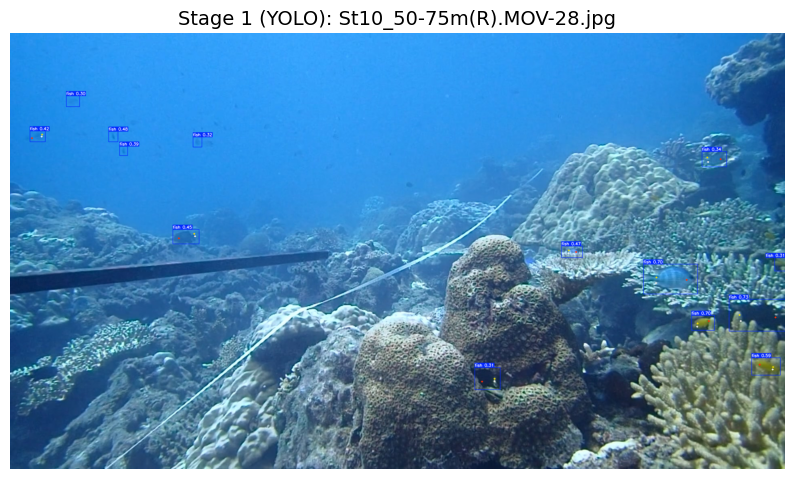

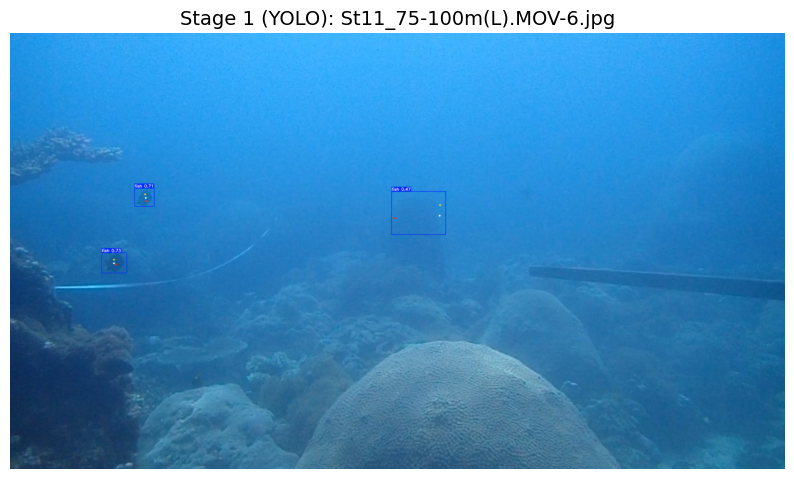

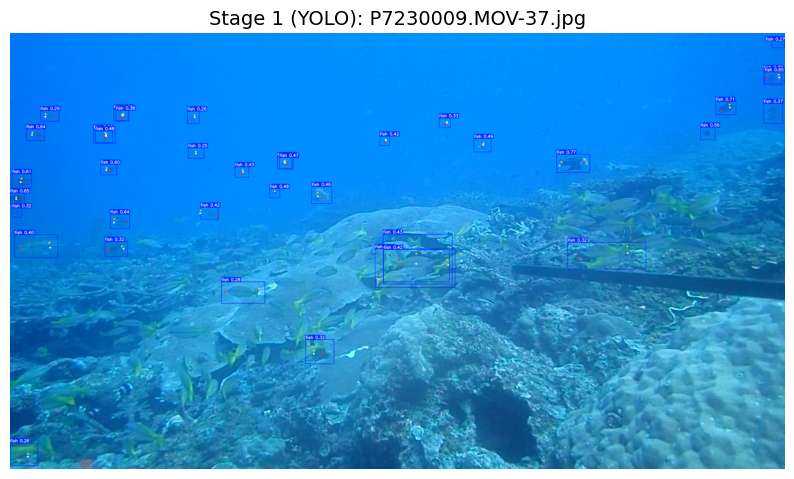

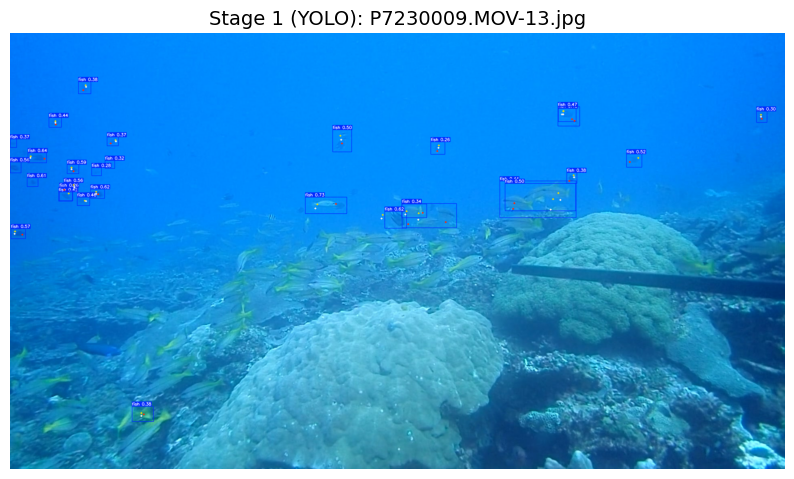

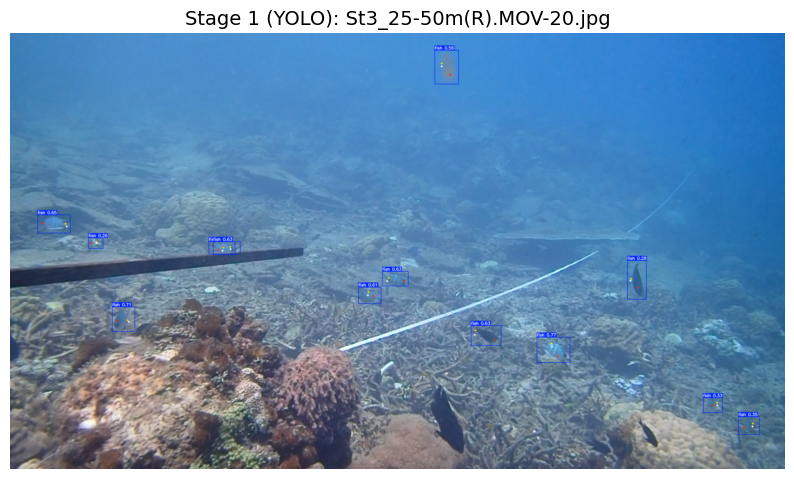

In [ ]:
# Cell 8: Stage 1 - YOLO Pose Annotations
import matplotlib.pyplot as plt

print("Generating Stage 1 (YOLO X-Ray) for the 5 selected images...")

for img_path in SELECTED_IMAGES:
    image_bgr = cv2.imread(img_path)
    
    # Run YOLO Inference
    results = yolo_model.predict(image_bgr, imgsz=1024, conf=0.2, rect=True, verbose=False)[0]
    
    # Generate the raw YOLO X-Ray image
    annotated_bgr = results.plot(line_width=1, font_size=1, kpt_radius=2)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    
    # Plot inline
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(annotated_rgb)
    ax.set_title(f"Stage 1 (YOLO): {os.path.basename(img_path)}", fontsize=14)
    ax.axis('off')
    plt.show()

Generating Stage 2 (SAM Masks) for ALL detected fish...


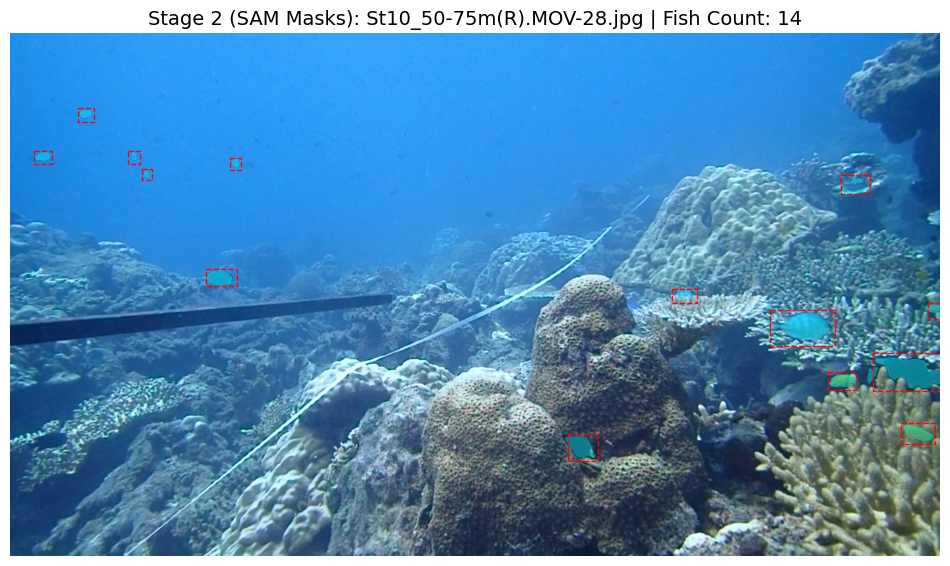

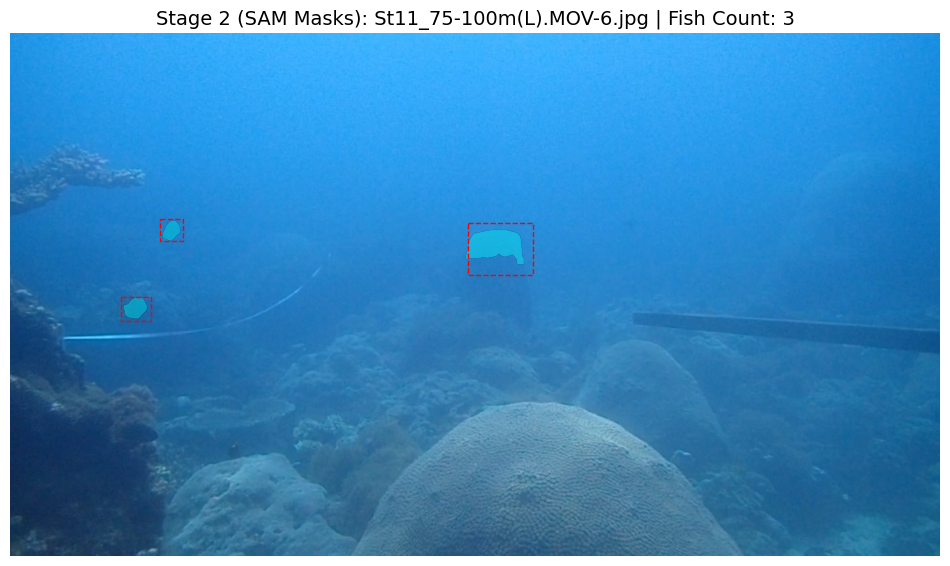

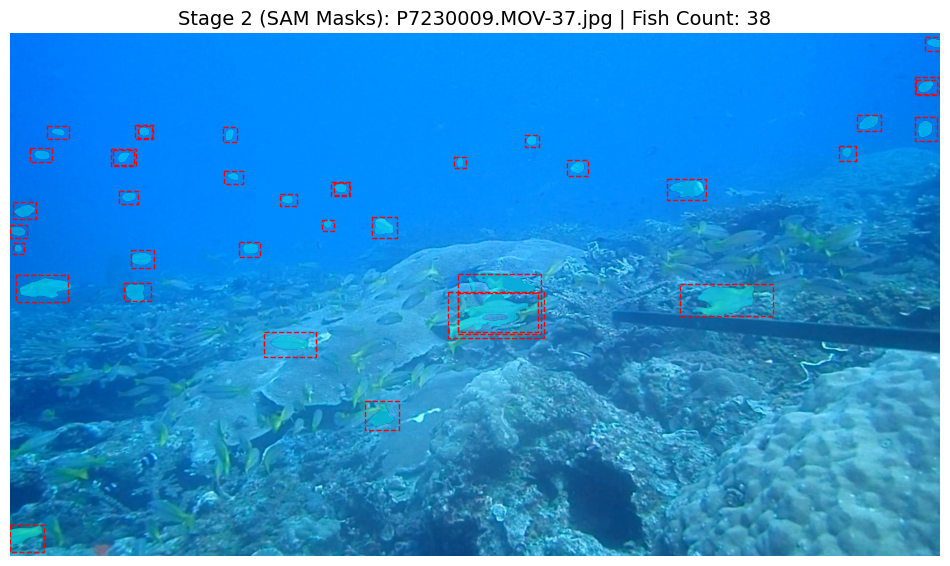

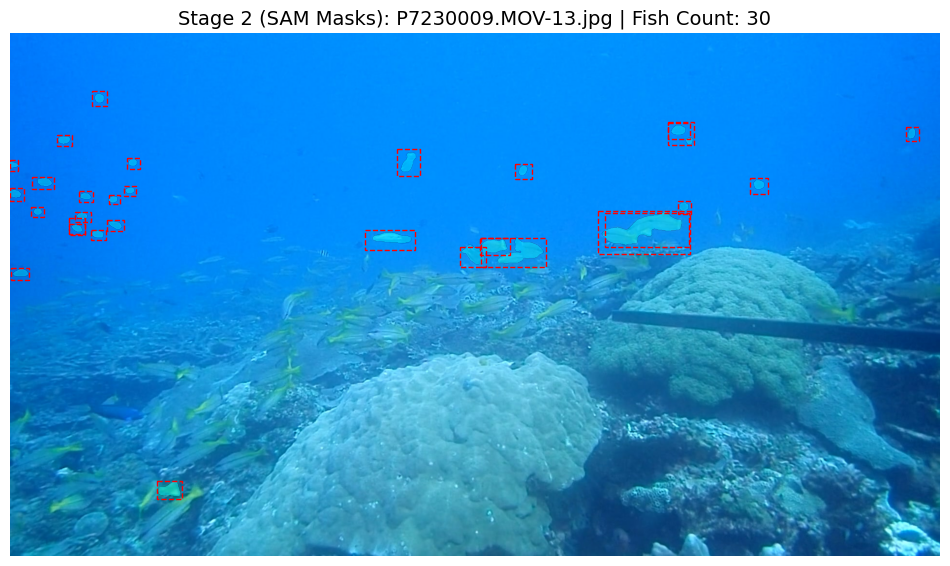

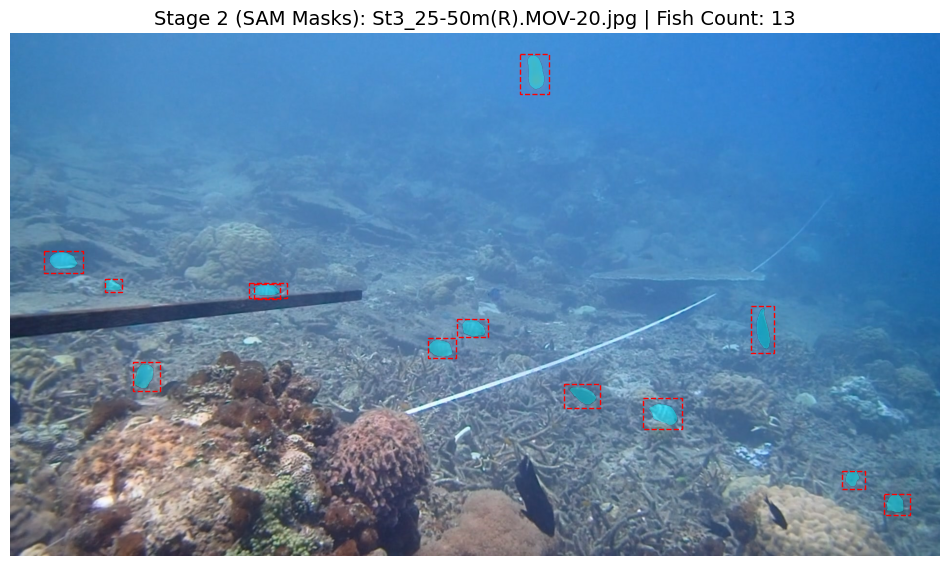

In [17]:
# Cell 9: Stage 2 - Zero-Shot Segmentation (Multi-Instance SAM)
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

print("Generating Stage 2 (SAM Masks) for ALL detected fish...")

for img_path in SELECTED_IMAGES:
    image_bgr = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    results = yolo_model.predict(image_bgr, imgsz=1024, conf=0.25, rect=True, verbose=False)[0]
    sam_predictor.set_image(image_rgb)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image_rgb) # Draw the real image first
    
    # --- THE FIX: Create ONE perfectly transparent RGBA canvas ---
    # Shape is (height, width, 4) for Red, Green, Blue, Alpha
    overlay_rgba = np.zeros((image_rgb.shape[0], image_rgb.shape[1], 4), dtype=np.float32)
    
    for j in range(len(results.boxes)):
        box = results.boxes.xyxy[j].cpu().numpy()
        
        masks, _, _ = sam_predictor.predict(box=box, multimask_output=False)
        best_mask = masks[0]
        
        # Paint the mask onto the transparent canvas
        # [0, 1, 1] is Cyan in 0-to-1 scale. [3] is the Alpha channel (opacity).
        overlay_rgba[best_mask, :3] = [0, 1, 1] 
        overlay_rgba[best_mask, 3] = 0.4        
        
        # Overlay YOLO Box
        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], fill=False, edgecolor='red', linewidth=1, linestyle='--')
        ax.add_patch(rect)
    
    # --- THE FIX: Overlay the combined transparent canvas ONCE after the loop ---
    ax.imshow(overlay_rgba)
    
    ax.set_title(f"Stage 2 (SAM Masks): {os.path.basename(img_path)} | Fish Count: {len(results.boxes)}", fontsize=14)
    ax.axis('off')
    plt.show()